# **TP : n-body problem**

## Imports

In [96]:
import numpy as np
import matplotlib.pyplot as plt

## Échauffement : le broadcasting

### 1.

In [97]:
a = np.array([1,2,3])
print(a)
print(f"La taille est {a.shape}.")
print(a[:,None])
print(f"La taille est {a[:,None].shape}.")
print(a[None,:])
print(f"La taille est {a[None,:].shape}.")

[1 2 3]
La taille est (3,).
[[1]
 [2]
 [3]]
La taille est (3, 1).
[[1 2 3]]
La taille est (1, 3).


`a[:,None]` est de taille (3,1) (3 lignes, 1 colonne), et `a[None,:]`est de taille (1,3) (1 ligne, 3 colonnes).

### 2.

In [98]:
print(a[:,None]-a[None,:])
print(f"La taille est {(a[:,None]-a[None,:]).shape}.")

[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]
La taille est (3, 3).


Pour calculer `a[:,None] - a[None,:]`, les deux tableaus sont étendus en taille (3,3) en dupliquant l'unique colonne / ligne. Puis on soustrait terme à terme. On obtient un tableau de taille (3,3). L'élement `[i,j]` correspond donc à `a[:,None][i:0] - a[None,:][0:j]`.

### 3.

In [99]:
b = np.array([[1,2,3],[4,5,6]])
print(b)
print(f"La taille est {b.shape}.")
print(b[:,None,:])
print(f"La taille est {b[:,None,:].shape}.")
print(b[:,:,None])
print(f"La taille est {b[:,:,None].shape}.")
print(b[:,None,:]-b[:,:,None])
print(f"La taille est {(b[:,None,:]-b[:,:,None]).shape}.")


[[1 2 3]
 [4 5 6]]
La taille est (2, 3).
[[[1 2 3]]

 [[4 5 6]]]
La taille est (2, 1, 3).
[[[1]
  [2]
  [3]]

 [[4]
  [5]
  [6]]]
La taille est (2, 3, 1).
[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]]
La taille est (2, 3, 3).


`b[:,None,:]`sera un tableau de taille (2,1,3) et `b[:,:,None]`sera un tableau de taille (2,3,1). On veut faire l'opération `b[:,None,:] - b[:,:,None]`. On compare les tailles par la droite : d'abord 3 vs 1, donc le 2eme tableau duplique ses données pour devenir de taille (2,3,3) dans le calcul. Ensuite 1 vs 3, donc le 1er tableau duplique ses données pour devenir de taille (2,3,3) dans le calcul. Enfin 2 vs 2 c'est bon. On peut maintenant soustraire terme à terme. L'élément [i,j,k] correspond donc à `b[:,None,:][i,0,k] - b[:,:,None][i,j,0]`.

## Initialisation aléatoire

In [100]:
# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.

In [101]:
def masse_aleatoire():
    return 3.*(1-np.random.random()) #sinon 0 est inclus)

def x_y_aleatoire():
    return np.random.uniform(-10.,10.)

def vitesse_aleatoire():
    return np.random.random()

def init_problem(N):
    masses = np.array([masse_aleatoire() for i in range(N)])
    positions = np.array([[x_y_aleatoire() for i in range(N)],[x_y_aleatoire() for i in range(N)]])
    speeds = np.array([[vitesse_aleatoire() for i in range(N)],[vitesse_aleatoire() for i in range(N)]])
    return masses, positions, speeds

masses, positions, speeds = init_problem(10)

try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("OK")
except:
    print("KO")

OK


## Initialisation reproductible

In [102]:
def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds

## Les forces

In [103]:
def forces(masses, positions, G=1.0):
    diff = positions[:,None,:] - positions[:,:,None]
    dist = np.linalg.norm(diff,axis=0)
    np.fill_diagonal(dist,np.inf)
    coeff = G * masses[:,None] * masses[None,:]
    forces = coeff[None,:,:] * diff / (dist[None,:,:]**3)
    force_totale = np.sum(forces,axis=2)
    return force_totale

masses,positions,speeds = init3()
f = forces(masses, positions)
np.all(np.isclose(f,np.array([[ 0.,-0.12257258,0.12257258],[0.,-0.02451452,0.02451452]])))

np.True_

## Le simulateur

In [104]:
def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    dim,N = positions.shape
    trajectoire = np.zeros((nb_steps,dim,N))
    for etape in range(nb_steps):
        trajectoire[etape,:,:] = positions
        accelerations = forces(masses,positions) / masses[None,:]
        speeds = speeds + accelerations*dt
        positions = positions + speeds*dt
    return trajectoire

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")

positions1 = s[1]

np.all(np.isclose(positions1, np.array([[0.,4.89877427,-4.89877427],[0.,0.99975485,-0.99975485]])))

shape OK


np.True_

## Dessiner

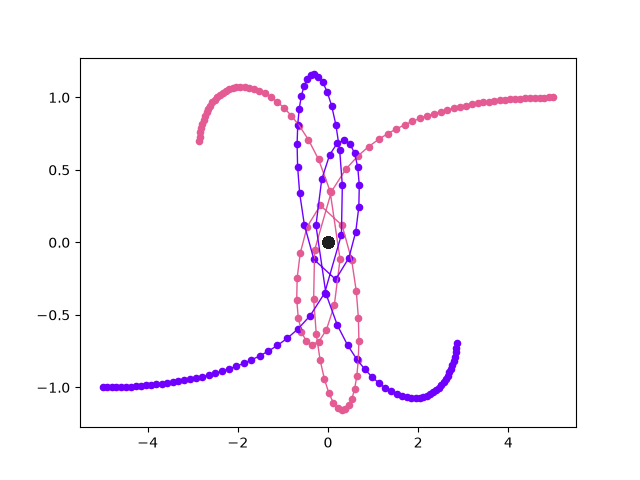

In [147]:
def draw(simulation, masses, colors=None, scale=10.):
    fig, ax = plt.subplots()
    for i in range(masses.shape[0]):
        x,y = simulation[:,:,i].T
        plt.plot(x,y,lw=1,color=colors[i])
        ax.scatter(x,y,color=colors[i],s=masses[i]*scale)
    plt.show()

masses, positions, speeds = init3()
colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255
draw(simulate(masses, positions, speeds), masses,colors=colors3,scale=20.)